In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from python_utils.visualization_utils import perc, SetPlotRC, ApplyFont, format_results_for_jupyter_and_latex, print_experiment_summary_hyperparams
from python_utils.visualization_utils import plot_pcl_convergence_ci, plot_pcl_convergence_w_quantiles, plot_pcl_convergence_boxplot

import warnings
warnings.filterwarnings("ignore")

In [2]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# Synthetic Low Dim Results with log cosh Loss Function

In [3]:
df_doubly_robustNME = pd.read_csv(r"../Results/Synthetic_Low_Dim_Experiment/DRPCLNET_SyntheticLowDim_Results_with_log_cosh_2000_5000_10000_15000_20000_2026-04-24_12-46-23.csv")
# df_doubly_robustNME = pd.read_csv(r"../Results/Synthetic_Low_Dim_Experiment/DRPCLNET_SyntheticLowDim_Results_with_MSEClosedForm_2000_5000_10000_15000_20000_2026-04-24_13-20-55.csv")
df_PKDR = pd.read_csv(r"../Results/Synthetic_Low_Dim_Experiment/PKDR_Synthetic_Low_Dim_Results_2000_5000_10000_15000_20000_2026-04-08_16-52-52.csv")
df_DRKPV = pd.read_csv(r"../Results/Synthetic_Low_Dim_Experiment/DRKPV_Synthetic_Low_Dim_Results_2000_5000_10000_15000_20000_2026-04-08_16-48-20.csv")
df_results = pd.concat([df_doubly_robustNME, df_DRKPV, df_PKDR], axis = 0)

df_doubly_robustNME.tail()

,Algorithm,Data_Size,Seed,Causal_MSE,out_experiment_name,out_disable_first_stage,out_lr_first_stage_base,out_lr_second_stage_ax,out_lr_second_stage_w,out_second_stage_head_lr,...,treat_negative_penalty,third_lr,third_weight_decay,third_n_epochs,third_gap_penalty_weight,third_log_per_epoch,third_input_dim,third_output_dim,third_hidden_dims,third_dropout_rate
595,DRPCLNET_Version2,20000,2800,0.004851,outcome_bridge_low_dim_v1,False,0.001,0.001,0.001,1.0,...,10.0,0.0005,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01
596,OutcomeBridgePCLNET,20000,2900,0.006043,outcome_bridge_low_dim_v1,False,0.001,0.001,0.001,1.0,...,10.0,0.0005,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01
597,TreatmentBridgePCLNET,20000,2900,0.203379,outcome_bridge_low_dim_v1,False,0.001,0.001,0.001,1.0,...,10.0,0.0005,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01
598,DRPCLNET_Version1,20000,2900,0.004783,outcome_bridge_low_dim_v1,False,0.001,0.001,0.001,1.0,...,10.0,0.0005,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01
599,DRPCLNET_Version2,20000,2900,0.003979,outcome_bridge_low_dim_v1,False,0.001,0.001,0.001,1.0,...,10.0,0.0005,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01


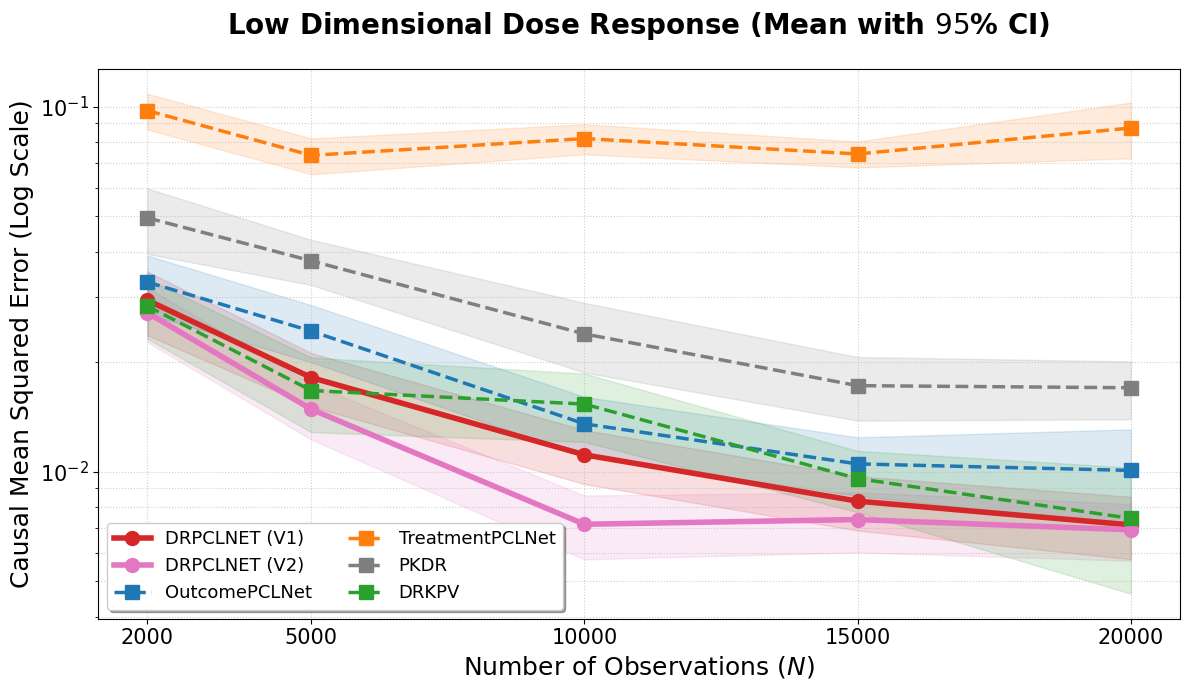

In [4]:
plot_title = f"Low Dimensional Dose Response (Mean with $95$% CI)"
low_dim_plot = plot_pcl_convergence_ci(df_results, title = plot_title)
plt.savefig('Figures/DRPCLNET_LowDimATE_Comparison.pdf', format='pdf', bbox_inches = 'tight')
low_dim_plot.show()

In [5]:
# plot_title = "Low Dimensional Dose Response"
# low_dim_plot = plot_pcl_convergence_w_quantiles(df_results, title = plot_title)
# # plt.savefig('Figures/DRPCLNET_LowDimATE_Comparison.pdf', format='pdf', bbox_inches = 'tight')
# low_dim_plot.show()

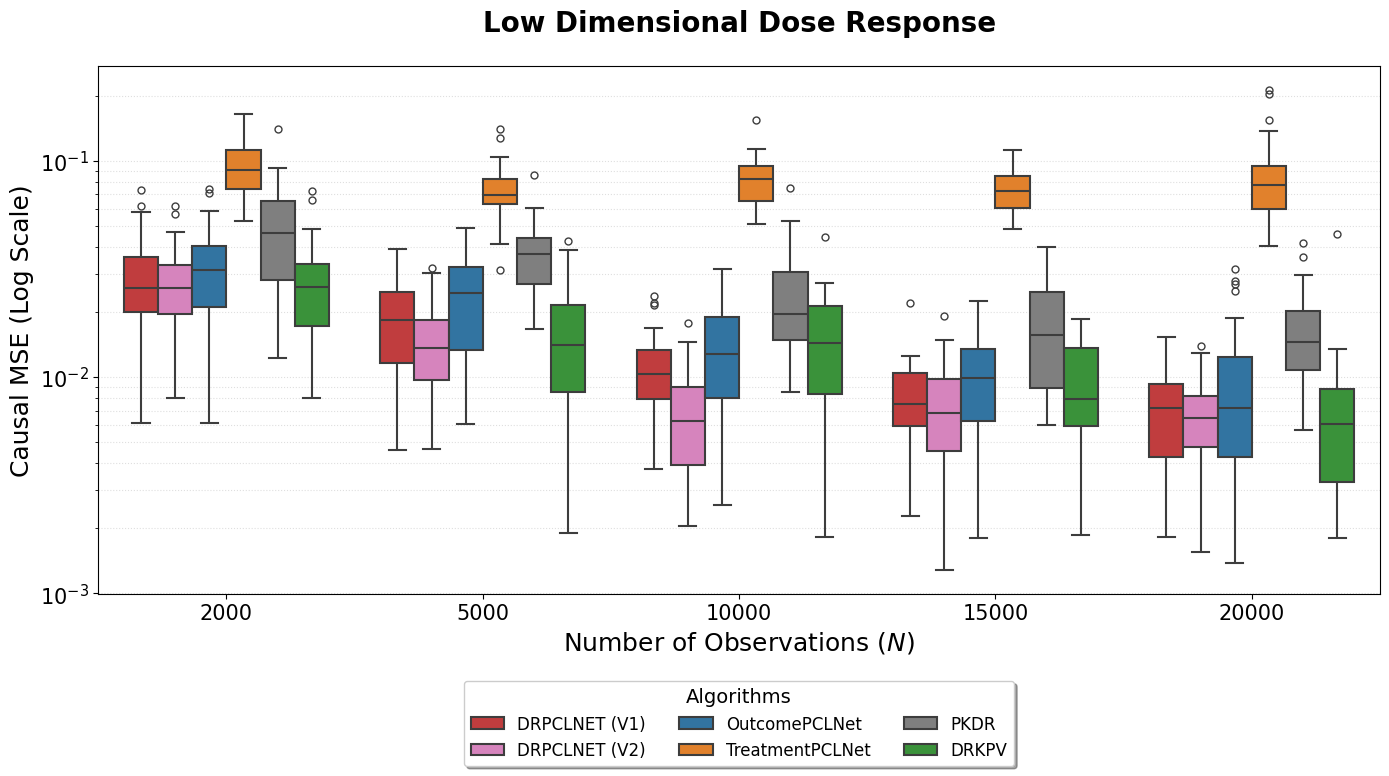

In [6]:
plot_title = "Low Dimensional Dose Response"
low_dim_boxplot = plot_pcl_convergence_boxplot(df_results, title = plot_title)
# plt.savefig('Figures/DRPCLNET_LowDimATE_Comparison_BoxPlot.pdf', format='pdf', bbox_inches = 'tight')
low_dim_boxplot.show()

In [7]:
format_results_for_jupyter_and_latex(df_results, "Low Dim ATE", precision=6)

--- Jupyter Visual Preview ---


In [8]:
print_experiment_summary_hyperparams(df_doubly_robustNME)

🚀 EXPERIMENT HYPERPARAMETER SUMMARY

📊 DATA SIZE: N = 2000
------------------------------

  🔹 Outcome Bridge (First/Second Stage):
    experiment_name          : outcome_bridge_low_dim_v1
    disable_first_stage      : False
    lr_first_stage_base      : 0.001
    lr_second_stage_ax       : 0.001
    lr_second_stage_w        : 0.001
    second_stage_head_lr     : 1.0
    weight_decay             : 1e-05
    first_stage_momentum     : 0.9
    second_stage_momentum    : 0.9
    scheduler_gamma          : 0.99
    n_epochs                 : 100.0
    stage1_iter              : 10.0
    stage2_iter              : 1.0
    second_stage_head_steps  : 10.0
    log_per_epoch            : 10.0
    plot_loss                : False
    reg_first_stage          : (0.0001, 0.01)
    reg_second_stage_first   : (1e-05, 0.001)
    reg_second_stage         : (0.001, 10.0)
    reg_annealing_method     : exponential
    consider_prev_weight     : True
    first_stage_loss_name    : mse
    second_stage_

# Synthetic Low Dim Results with Other Loss Functions

In [9]:
df_NME_huber = pd.read_csv(r"../Results/Synthetic_Low_Dim_Experiment/DRPCLNET_SyntheticLowDim_Results_with_huber_2000_5000_10000_15000_20000_2026-04-24_12-47-01.csv")

In [10]:
format_results_for_jupyter_and_latex(df_NME_huber, "Low Dim ATE", precision=6)

--- Jupyter Visual Preview ---


In [11]:
df_NME_mse = pd.read_csv(r"../Results/Synthetic_Low_Dim_Experiment/DRPCLNET_SyntheticLowDim_Results_with_MSE_and_SGD_2000_5000_10000_15000_20000_2026-04-24_13-11-09.csv")

In [12]:
format_results_for_jupyter_and_latex(df_NME_mse, "Low Dim ATE", precision=6)

--- Jupyter Visual Preview ---


In [13]:
df_NME_mse_closed_form = pd.read_csv(r"../Results/Synthetic_Low_Dim_Experiment/DRPCLNET_SyntheticLowDim_Results_with_MSEClosedForm_2000_5000_10000_15000_20000_2026-04-24_13-20-55.csv")

In [14]:
format_results_for_jupyter_and_latex(df_NME_mse_closed_form, "Low Dim ATE", precision=6)

--- Jupyter Visual Preview ---


# Misspecification Analysis

In [15]:
df_NME = pd.read_csv(r"../Results/Synthetic_Low_Dim_Experiment/DRPCLNET_SyntheticLowDim_Misspecified_Results_with_log_cosh_noisy_proxies_2026-04-27_17-03-30.csv")
df_NME.tail()

,Algorithm,Data_Size,Seed,Scenario,Causal_MSE,Estimated_Response,Treatment_Grid,Ground_Truth_Response,out_experiment_name,out_disable_first_stage,...,treat_negative_penalty,third_lr,third_weight_decay,third_n_epochs,third_gap_penalty_weight,third_log_per_epoch,third_input_dim,third_output_dim,third_hidden_dims,third_dropout_rate
355,DRPCLNET_Version2,2000,2900,broken_z,0.109787,"[1.364250898361206, 1.4854426383972168, 1.6015...","[-1.0, -0.9696969696969697, -0.939393939393939...","[1.8469182819612462, 1.8955073797900825, 1.991...",outcome_bridge_low_dim_v1,False,...,10.0,0.001,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01
356,OutcomeBridgePCLNET,2000,2900,broken_both,0.116059,"[1.30362069606781, 1.4291579723358154, 1.54958...","[-1.0, -0.9696969696969697, -0.939393939393939...","[1.8469182819612462, 1.8955073797900825, 1.991...",outcome_bridge_low_dim_v1,False,...,10.0,0.001,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01
357,TreatmentBridgePCLNET,2000,2900,broken_both,0.123570,"[1.1607966423034668, 1.2628246545791626, 1.363...","[-1.0, -0.9696969696969697, -0.939393939393939...","[1.8469182819612462, 1.8955073797900825, 1.991...",outcome_bridge_low_dim_v1,False,...,10.0,0.001,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01
358,DRPCLNET_Version1,2000,2900,broken_both,0.105261,"[1.245509147644043, 1.3690201044082642, 1.4874...","[-1.0, -0.9696969696969697, -0.939393939393939...","[1.8469182819612462, 1.8955073797900825, 1.991...",outcome_bridge_low_dim_v1,False,...,10.0,0.001,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01
359,DRPCLNET_Version2,2000,2900,broken_both,0.081369,"[1.3333650827407837, 1.4570631980895996, 1.574...","[-1.0, -0.9696969696969697, -0.939393939393939...","[1.8469182819612462, 1.8955073797900825, 1.991...",outcome_bridge_low_dim_v1,False,...,10.0,0.001,0.000001,100.0,0.0,10.0,1.0,1.0,"[32, 64]",0.01


In [16]:
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If you already have df loaded, skip this line.
# df = pd.read_csv("PATH_TO_YOUR_RESULTS.csv")

df = df_NME.copy()
def parse_array(x):
    if isinstance(x, np.ndarray):
        return x.reshape(-1)
    if isinstance(x, list):
        return np.asarray(x, dtype=float).reshape(-1)

    try:
        return np.asarray(json.loads(x), dtype=float).reshape(-1)
    except Exception:
        return np.asarray(ast.literal_eval(x), dtype=float).reshape(-1)

df["est"] = df["Estimated_Response"].apply(parse_array)
df["grid"] = df["Treatment_Grid"].apply(parse_array)
df["truth"] = df["Ground_Truth_Response"].apply(parse_array)

# Sanity check
df["MSE_check"] = df.apply(lambda r: np.mean((r["est"] - r["truth"]) ** 2), axis=1)
print("Max MSE mismatch:", np.max(np.abs(df["Causal_MSE"] - df["MSE_check"])))

Max MSE mismatch: 9.71445146547012e-17


In [17]:
mse_summary = (
    df.groupby(["Scenario", "Algorithm"])
      .agg(
          mean_mse=("Causal_MSE", "mean"),
          se_mse=("Causal_MSE", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
          std_mse=("Causal_MSE", "std"),
          n_seeds=("Causal_MSE", "count"),
      )
      .reset_index()
)

mse_summary["mean ± se"] = mse_summary.apply(
    lambda r: f"{r['mean_mse']:.4g} ± {r['se_mse']:.2g}",
    axis=1,
)

mse_table = mse_summary.pivot_table(
    index="Scenario",
    columns="Algorithm",
    values="mean ± se",
    aggfunc="first",
)

mse_table

Algorithm,DRPCLNET_Version1,DRPCLNET_Version2,OutcomeBridgePCLNET,TreatmentBridgePCLNET
Scenario,,,,
broken_both,0.1475 ± 0.0071,0.1351 ± 0.0065,0.164 ± 0.0073,0.1527 ± 0.0052
broken_w,0.1468 ± 0.0067,0.1407 ± 0.0072,0.1562 ± 0.0073,0.1506 ± 0.0052
broken_z,0.134 ± 0.008,0.1236 ± 0.0076,0.1433 ± 0.0082,0.1661 ± 0.0087


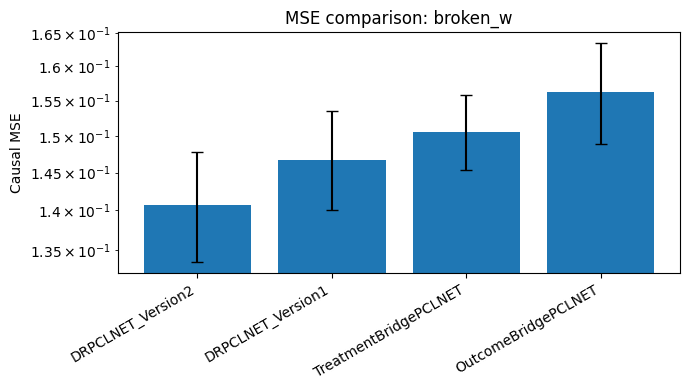

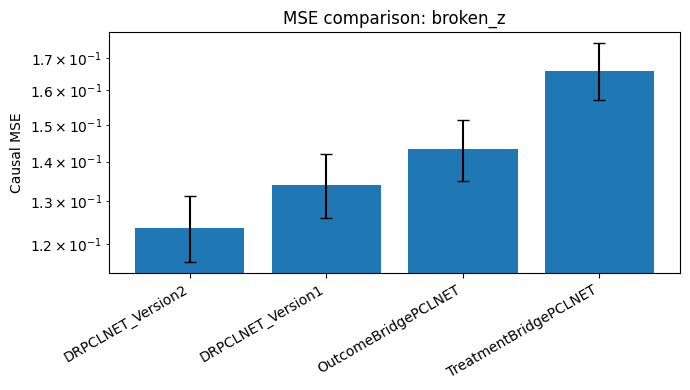

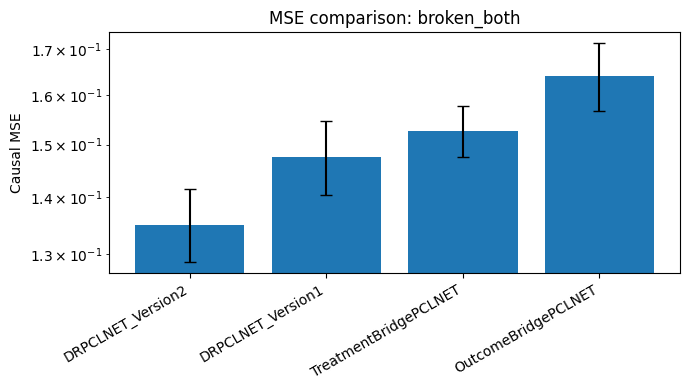

In [18]:
def plot_mse_bar(df, scenario):
    sub = mse_summary[mse_summary["Scenario"] == scenario].copy()
    sub = sub.sort_values("mean_mse")

    plt.figure(figsize=(7, 4))
    plt.bar(sub["Algorithm"], sub["mean_mse"], yerr=sub["se_mse"], capsize=4)
    plt.yscale("log")
    plt.ylabel("Causal MSE")
    plt.title(f"MSE comparison: {scenario}")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

for scenario in df["Scenario"].unique():
    plot_mse_bar(df, scenario)

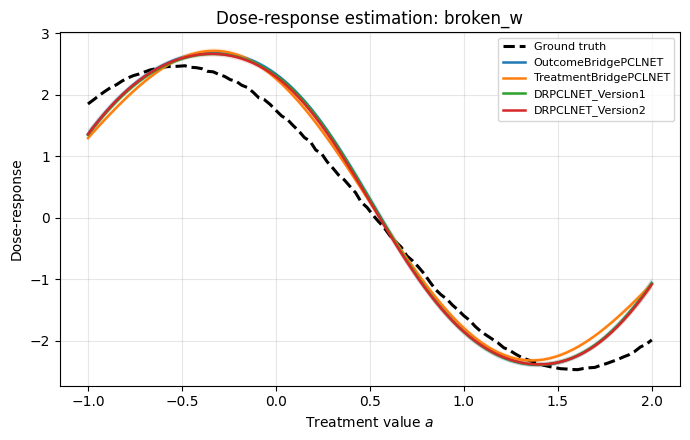

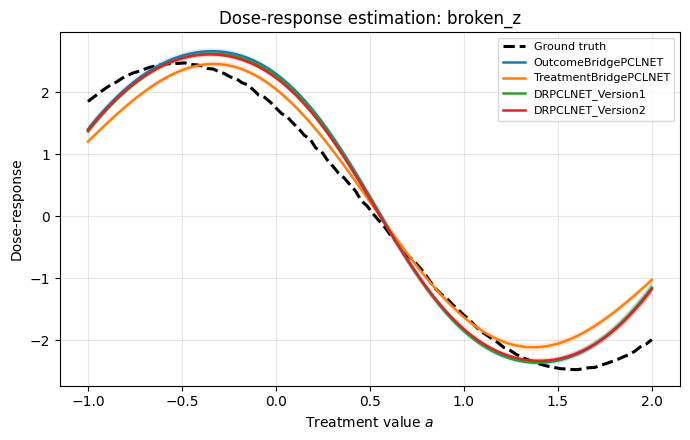

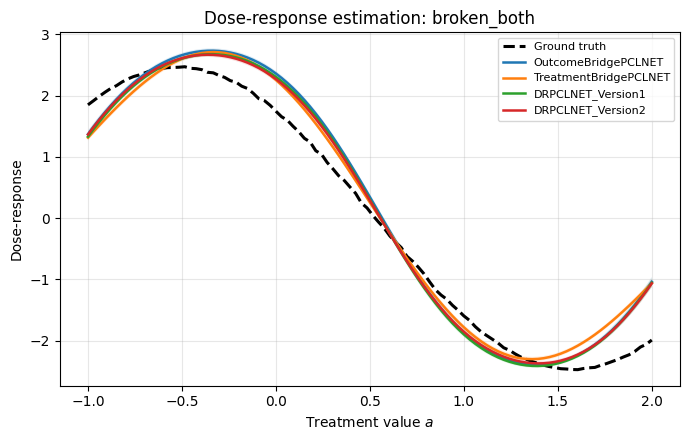

In [19]:
def plot_dose_response_curves(df, scenario, ci=True):
    sub = df[df["Scenario"] == scenario].copy()

    plt.figure(figsize=(7, 4.5))

    # Ground truth from first row
    grid = sub.iloc[0]["grid"]
    truth = sub.iloc[0]["truth"]
    plt.plot(grid, truth, "k--", linewidth=2.2, label="Ground truth")

    for alg in sub["Algorithm"].unique():
        alg_sub = sub[sub["Algorithm"] == alg]
        curves = np.stack(alg_sub["est"].values)

        mean_curve = curves.mean(axis=0)
        se_curve = curves.std(axis=0, ddof=1) / np.sqrt(curves.shape[0])

        plt.plot(grid, mean_curve, linewidth=1.8, label=alg)

        if ci:
            plt.fill_between(
                grid,
                mean_curve - 1.96 * se_curve,
                mean_curve + 1.96 * se_curve,
                alpha=0.15,
            )

    plt.xlabel("Treatment value $a$")
    plt.ylabel("Dose-response")
    plt.title(f"Dose-response estimation: {scenario}")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for scenario in df["Scenario"].unique():
    plot_dose_response_curves(df, scenario)